# Train XGBoost

In [1]:
import sys
print(sys.executable)
print(sys.version)

d:\Documents\Projects\WorldCup-Predictor\.venv\Scripts\python.exe
3.11.8 (tags/v3.11.8:db85d51, Feb  6 2024, 22:03:32) [MSC v.1937 64 bit (AMD64)]


### I'll load the dataset in this notebook as well and thne create X and Y, and finally split the data in the same way.

In [5]:
import pandas as pd

training_data = pd.read_csv("../data/processed/training_data.csv")

In [6]:
X = training_data.drop(columns=["target"])
y = training_data["target"]

In [8]:
split_index = int(len(training_data) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

### Train XGBoost

In [9]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    objective="multi:softmax",
    num_class=3,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

In [10]:
xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import lo

### Prediction

In [11]:
xgb_predictions = xgb_model.predict(X_test)

### Accuracy

In [13]:
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [14]:
accuracy = accuracy_score(
    y_test,
    xgb_predictions
)

print(accuracy)

0.5581184528605962


### Classification Report

In [15]:
print(
    classification_report(
        y_test,
        xgb_predictions
    )
)

              precision    recall  f1-score   support

           0       0.52      0.53      0.52      2881
           1       0.28      0.02      0.04      2311
           2       0.58      0.84      0.69      4736

    accuracy                           0.56      9928
   macro avg       0.46      0.46      0.42      9928
weighted avg       0.49      0.56      0.49      9928



### Confusion Matrix

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

Matplotlib is building the font cache; this may take a moment.


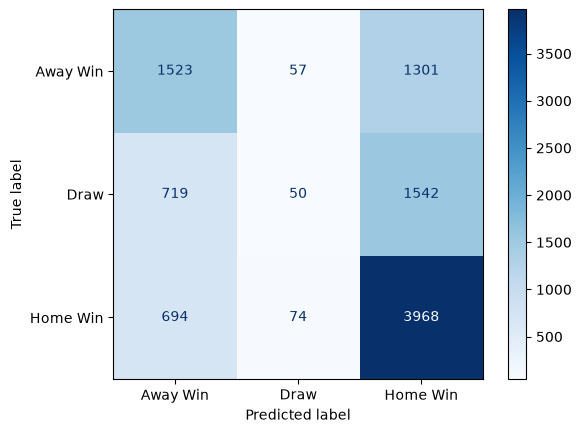

In [18]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    xgb_predictions,
    display_labels=["Away Win","Draw","Home Win"],
    cmap="Blues"
)

plt.show()

### Saving the model

In [19]:
import joblib

joblib.dump(
    xgb_model,
    "../models/worldcup_predictor.joblib"
)

['../models/worldcup_predictor.joblib']

In [20]:
X_train.columns

Index(['home_avg_goals', 'away_avg_goals', 'home_avg_goals_against',
       'away_avg_goals_against', 'home_win_rate', 'away_win_rate',
       'home_goal_difference', 'away_goal_difference', 'home_career_matches',
       'away_career_matches', 'neutral'],
      dtype='str')

In [21]:
X.columns

Index(['home_avg_goals', 'away_avg_goals', 'home_avg_goals_against',
       'away_avg_goals_against', 'home_win_rate', 'away_win_rate',
       'home_goal_difference', 'away_goal_difference', 'home_career_matches',
       'away_career_matches', 'neutral'],
      dtype='str')